In [7]:
%run functions.ipynb

In [8]:
from sklearn.linear_model import LinearRegression

df = load_data()

# Seleccion del numero de rezagos con una validacion dentro del
# entrenamiento: se reservan los ultimos 24 meses del entrenamiento.
train = df.yt_true.iloc[:-24]

validacion = {}

for p_max in (12, 13, 24, 36):
    forecast = recursive_forecast(LinearRegression(), train, p_max)
    validacion[p_max] = np.mean(np.abs(train.values[-24:] - forecast[-24:]))

pd.Series(validacion, name="MAE validacion").round(1)

12    564.7
13    507.0
24    501.1
36    385.4
Name: MAE validacion, dtype: float64

P_MAX = 36


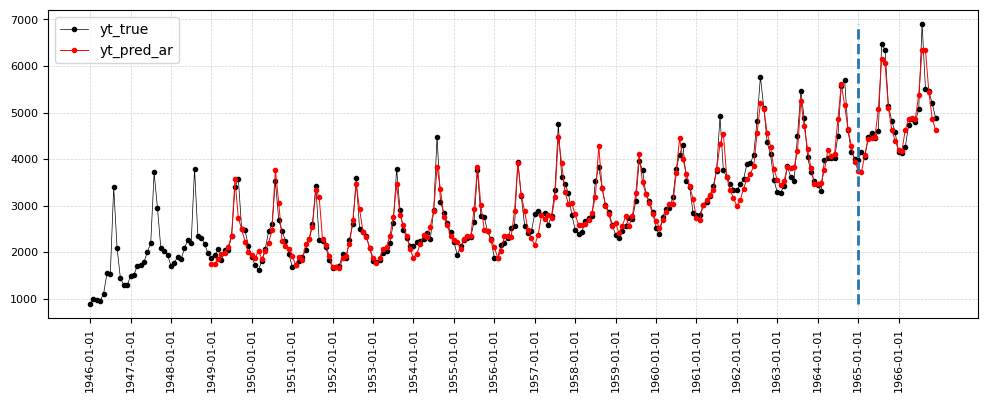

In [9]:
# Se usa el numero de rezagos con menor error de validacion; el tramo
# de prueba no interviene en la eleccion.

P_MAX = min(validacion, key=validacion.get)
print("P_MAX =", P_MAX)

df["yt_pred_ar"] = recursive_forecast(LinearRegression(), df.yt_true, P_MAX)

plot_time_series(df[["yt_true", "yt_pred_ar"]])

In [10]:
metrics = compute_evaluation_metrics(df)
save_forecasts(df)
save_metrics(metrics)
metrics

,Metrics,yt_pred_ar
0,MSE Train,50533.08
1,MSE Test,92327.44
2,MAE Train,160.48
3,MAE Test,224.08
